# Linear SVM - Email Spam Classifier


In this section, we'll build a linear SVM classifier to classify emails into spam and ham. The dataset, **spambase**, is taken from the UCI ML repository and contains about 4600 emails labelled as **spam** or **ham**. 

## Data Understanding

Let's first load the data and understand the attributes meanings, shape of the dataset etc.

In [25]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import validation_curve
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

#### Data Loading

In [26]:
# load the data
email_rec = pd.read_csv("Spam.csv")
email_rec.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_hash,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [27]:
# look at dimensions of the df
print(email_rec.shape)

(4601, 58)


In [28]:
# ensure that data type are correct
email_rec.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

#### Null Values and Class Proportions

In [29]:
# there are no missing values in the dataset 
email_rec.isnull().sum()

word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_freq_our                 0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_lab                 0
word_freq_labs                0
word_freq_telnet              0
word_fre

Let's also look at the fraction of spam and ham emails in the dataset.

In [30]:
# look at fraction of spam emails 
email_rec['spam'].describe()

count    4601.000000
mean        0.394045
std         0.488698
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: spam, dtype: float64

This shows around 39% of the mails are spam

## Data Preparation

Let's now conduct some prelimininary data preparation steps, i.e. rescaling the variables, splitting into train and test etc. To understand why rescaling is required, let's print the summary stats of all columns.

You will notice that the columns at the end (`capital_run_length_longest`, `capital_run_length_total` etc.) have much higher values (means = 52, 283 etc.) than most other columns which represent fraction of word occurrences ($\frac{\text{no. of times word appears in email}}{\text{total no. of words in email}}$).

In [31]:
email_rec.describe()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_hash,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,...,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,0.104553,0.213015,0.280656,0.065425,0.312223,0.095901,0.114208,0.105295,0.090067,0.239413,...,0.038575,0.139030,0.016976,0.269071,0.075811,0.044238,5.191515,52.172789,283.289285,0.394045
std,0.305358,1.290575,0.504143,1.395151,0.672513,0.273824,0.391441,0.401071,0.278616,0.644755,...,0.243471,0.270355,0.109394,0.815672,0.245882,0.429342,31.729449,194.891310,606.347851,0.488698
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.588000,6.000000,35.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.065000,0.000000,0.000000,0.000000,0.000000,2.276000,15.000000,95.000000,0.000000
75%,0.000000,0.000000,0.420000,0.000000,0.380000,0.000000,0.000000,0.000000,0.000000,0.160000,...,0.000000,0.188000,0.000000,0.315000,0.052000,0.000000,3.706000,43.000000,266.000000,1.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000,1.000000


#### Data Split and Scaling

We must first split to avoid any data leakage

In [32]:
# splitting into X and y
X = email_rec.drop("spam", axis=1)
y = email_rec["spam"].astype(int)

In [33]:
# split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=4, stratify=y)

In [34]:
# scaling the features using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [35]:
# confirm that splitting also has similar distribution of spam and ham emails
print(y_train.mean())
print(y_test.mean())

0.3940993788819876
0.3939174511223751


## Model Building

Let's build a linear SVM mode now. The ```SVC()``` class does that in sklearn. We highly recommend reading the documentation at least once.

In [36]:
help(SVC)

Help on class SVC in module sklearn.svm._classes:

class SVC(sklearn.svm._base.BaseSVC)
 |  SVC(
 |      *,
 |      C=1.0,
 |      kernel='rbf',
 |      degree=3,
 |      gamma='scale',
 |      coef0=0.0,
 |      shrinking=True,
 |      probability=False,
 |      tol=0.001,
 |      cache_size=200,
 |      class_weight=None,
 |      verbose=False,
 |      max_iter=-1,
 |      decision_function_shape='ovr',
 |      break_ties=False,
 |      random_state=None
 |  )
 |
 |  C-Support Vector Classification.
 |
 |  The implementation is based on libsvm. The fit time scales at least
 |  quadratically with the number of samples and may be impractical
 |  beyond tens of thousands of samples. For large datasets
 |  consider using :class:`~sklearn.svm.LinearSVC` or
 |  :class:`~sklearn.linear_model.SGDClassifier` instead, possibly after a
 |  :class:`~sklearn.kernel_approximation.Nystroem` transformer or
 |  other :ref:`kernel_approximation`.
 |
 |  The multiclass support is handled according to a

**Note**: The `C` we use here is the inverse of what we learnt in theory

Another important point to note is that the SVC takes an argument, `kernel` (default value `'rbf'`), which specifies the type of SVC we are using. **We will learn what *kernel* and *'rbf'* mean later**, when we get to discussing other types of (non-linear) SVMs. For now, we will set this argument as `kernel='linear'`.


Let's first build a basic model without trying to optimise the hyperparameter `C`

In [37]:
# Model building

# instantiate an object of class SVC() of linear type
# note that we are using cost C=1
model = SVC(kernel='linear', C = 1)

# fit
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

In [38]:
model

,C,1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


#### Evaluation of Baseline Model

In [39]:
# Evaluate the model using confusion matrix 
from sklearn import metrics
metrics.confusion_matrix(y_true=y_test, y_pred=y_pred)

array([[796,  41],
       [ 82, 462]])

In [40]:
# accuracy
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

# precision
print("Precision:", metrics.precision_score(y_test, y_pred))

# recall/sensitivity
print("Recall:", metrics.recall_score(y_test, y_pred))

Accuracy: 0.9109341057204924
Precision: 0.9184890656063618
Recall: 0.8492647058823529


In [ ]:
# specificity (% of hams correctly classified)
print("Specificity:", 796/(796+41))     # use values from the confusion matrix here

#### Interpretation of Results

In the confusion matrix, the elements at `(0, 0)` and `(1,1)` correspond to the more frequently occurring class, i.e. *ham* emails. Thus, it implies that:
- 91% of all emails are classified correctly
- 85% of spams are identified correctly (sensitivity/recall)
- Specificity, or % of hams classified correctly, is 95%



## Hyperparameter Tuning

### K-Fold Cross Validation

Let's first run a simple k-fold cross validation to get a sense of the **average metrics** as computed over multiple *folds*. The easiest way to do cross-validation is to use the ```cross_val_score()``` function.

In [42]:
# creating a KFold object with 5 splits - 5 fold of the data
# this KFold object will be sent to the cross validation function
folds = KFold(n_splits = 5, shuffle = True, random_state = 4)

# instantiating a model with cost=1
model = SVC(kernel='linear', C = 1)

In [43]:
# computing the cross-validation scores 
# note that the argument cv takes the 'folds' object, and
# we have specified 'accuracy' as the metric for tuning in CV

cv_results = cross_val_score(model, X_train, y_train, cv = folds, scoring = 'accuracy') 

In [44]:
# print 5 accuracies obtained from the 5 folds
print(cv_results)
print("mean accuracy = {}".format(cv_results.mean()))

[0.94875776 0.9378882  0.92236025 0.91459627 0.92701863]
mean accuracy = 0.9301242236024845


We see a minor improvement in accuracy. Let's see if tuning for `C` has any effect on this.

### Grid Search to Find Optimal Hyperparameter C

K-fold CV helps us compute average metrics over multiple folds, and that is the best indication of the 'test accuracy/other metric scores' we can have. 

But we want to use CV to compute the optimal values of hyperparameters (in this case, the cost `C` is a hyperparameter). This is done using the `GridSearchCV()` method, which computes metrics (such as accuracy, recall etc.) 

In this case, we have only one hyperparameter, though you can have multiple, such as `C` and `gamma` in non-linear SVMs. In that case, you need to search through a *grid* of multiple values from each of those hyperparameters to find the optimal combination, and hence the name Grid Search CV.

In [45]:
# specify range of parameters (C) as a list
params = {"C": [0.001, 0.01, 0.1, 1, 10, 50, 100, 300]}

model = SVC(kernel='linear')

# set up grid search scheme
# note that we are still using the 5 fold CV scheme we set up earlier
model_cv = GridSearchCV(estimator = model, param_grid = params, 
                        scoring= 'accuracy', cv = folds,
                        verbose = 5, return_train_score=True)      

In [46]:
# fit the model - it will fit 5 folds across all values of C
model_cv.fit(X_train, y_train)  

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV 1/5] END .......C=0.001;, score=(train=0.877, test=0.888) total time=   0.0s
[CV 2/5] END .......C=0.001;, score=(train=0.882, test=0.899) total time=   0.0s
[CV 3/5] END .......C=0.001;, score=(train=0.882, test=0.866) total time=   0.0s
[CV 4/5] END .......C=0.001;, score=(train=0.884, test=0.871) total time=   0.0s
[CV 5/5] END .......C=0.001;, score=(train=0.885, test=0.870) total time=   0.0s
[CV 1/5] END ........C=0.01;, score=(train=0.914, test=0.938) total time=   0.0s
[CV 2/5] END ........C=0.01;, score=(train=0.918, test=0.921) total time=   0.0s
[CV 3/5] END ........C=0.01;, score=(train=0.919, test=0.904) total time=   0.0s
[CV 4/5] END ........C=0.01;, score=(train=0.927, test=0.901) total time=   0.0s
[CV 5/5] END ........C=0.01;, score=(train=0.919, test=0.908) total time=   0.0s
[CV 1/5] END .........C=0.1;, score=(train=0.929, test=0.946) total time=   0.0s
[CV 2/5] END .........C=0.1;, score=(train=0.931,

,estimator,SVC(kernel='linear')
,param_grid,"{'C': [0.001, 0.01, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,5
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,C,100


In [47]:
# results of grid search CV
cv_results = pd.DataFrame(model_cv.cv_results_)
cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.073696,0.013840,0.012132,0.000777,0.001,{'C': 0.001},0.888199,0.899068,0.866460,0.871118,...,0.878882,0.012615,8,0.877329,0.881599,0.881599,0.883929,0.885481,0.881988,0.002756
1,0.047752,0.001979,0.007916,0.000588,0.010,{'C': 0.01},0.937888,0.920807,0.903727,0.900621,...,0.914286,0.013658,7,0.913820,0.918478,0.918866,0.927019,0.919255,0.919488,0.004250
2,0.051068,0.001821,0.006306,0.000679,0.100,{'C': 0.1},0.945652,0.933230,0.919255,0.916149,...,0.927329,0.010821,6,0.928960,0.930901,0.928960,0.935947,0.935947,0.932143,0.003186
3,0.149333,0.015018,0.005174,0.000552,1.000,{'C': 1},0.948758,0.937888,0.922360,0.914596,...,0.930124,0.011988,5,0.931289,0.934006,0.934394,0.940217,0.937888,0.935559,0.003135
4,0.676988,0.059008,0.005665,0.000717,10.000,{'C': 10},0.953416,0.937888,0.920807,0.920807,...,0.931988,0.012399,2,0.931289,0.935947,0.934006,0.940606,0.942547,0.936879,0.004156
5,4.245392,0.221244,0.005080,0.000281,50.000,{'C': 50},0.950311,0.939441,0.920807,0.919255,...,0.931366,0.011842,4,0.933618,0.936335,0.934394,0.940606,0.940606,0.937112,0.002987
6,7.536360,1.336627,0.004864,0.000312,100.000,{'C': 100},0.947205,0.942547,0.923913,0.920807,...,0.932298,0.010559,1,0.934006,0.935947,0.934783,0.940994,0.942158,0.937578,0.003343
7,23.066159,2.512605,0.005047,0.000097,300.000,{'C': 300},0.947205,0.944099,0.922360,0.920807,...,0.931988,0.011300,2,0.931289,0.935171,0.935559,0.940994,0.941382,0.936879,0.003824


To get a better sense of how training and test accuracy varies with C, let's plot the tranining and test accuracies against C.

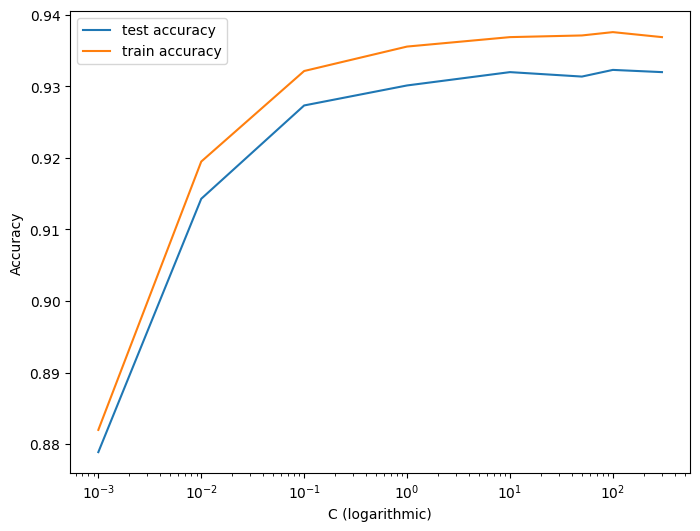

In [48]:
# plot of C versus train and test scores

plt.figure(figsize=(8, 6))
plt.plot(cv_results['param_C'], cv_results['mean_test_score'])
plt.plot(cv_results['param_C'], cv_results['mean_train_score'])
plt.xlabel('C (logarithmic)')
plt.ylabel('Accuracy')
plt.legend(['test accuracy', 'train accuracy'], loc='upper left')
plt.xscale('log')

As we noted earlier, this `C` is inverse of the $C$ we discussed while learning the theory. We said that reducing $C$ will reduce the overall error ($\sum \epsilon_i < C$), but here, we can see that as `C` decreases, the error is increasing (because `C` is 1/$C$). 


*From here on, we will be referring to the sklearn `C` when we talk about C in coding demonstrations.*


Though the training accuracy monotonically increases with C, the test accuracy gradually reduces. Thus, we can conclude that higher values of C tend to **overfit** the model. This is because a high C value aims to classify all training examples correctly (since C is the *cost of misclassification* - if you impose a high cost on the model, it will avoid misclassifying any points by overfitting the data). 



Let's finally look at the optimal `C` values found by `GridSearchCV`.

In [49]:
best_score = model_cv.best_score_
best_C = model_cv.best_params_['C']

print(" The highest test (val) accuracy is {0} at C = {1}".format(best_score, best_C))

 The highest test (val) accuracy is 0.9322981366459627 at C = 100


Let's now look at the metrics corresponding to C=100

In [50]:
# model with the best value of C
model = SVC(kernel='linear',C=best_C)

# fit
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

In [51]:
# accuracy
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

# precision
print("Precision:", metrics.precision_score(y_test, y_pred))

# recall/sensitivity
print("Recall:", metrics.recall_score(y_test, y_pred))

Accuracy: 0.9116582186821144
Precision: 0.9169960474308301
Recall: 0.8529411764705882


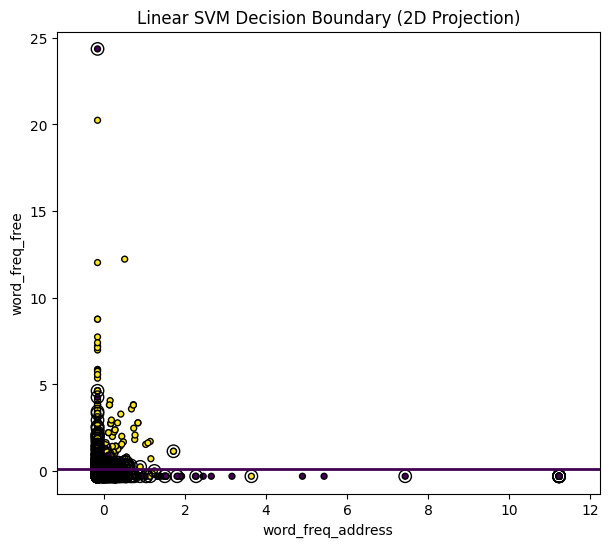

In [55]:
# pick the two best features
feat1 = "word_freq_address"
feat2 = "word_freq_free"

# get column indices
i1 = list(X.columns).index(feat1)
i2 = list(X.columns).index(feat2)

# slice from the scaled NumPy arrays
X2_train = X_train[:, [i1, i2]]
X2_test  = X_test[:, [i1, i2]]

# fit a 2D model for plotting
svm2d = SVC(kernel='linear', C=1)
svm2d.fit(X2_train, y_train)

# meshgrid
x_min, x_max = X2_train[:, 0].min() - 1, X2_train[:, 0].max() + 1
y_min, y_max = X2_train[:, 1].min() - 1, X2_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

# decision boundary
Z = svm2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7,6))
plt.contour(xx, yy, Z, levels=[0.5], linewidths=2)

plt.scatter(X2_train[:,0], X2_train[:,1], c=y_train, s=18, edgecolors="k")
plt.scatter(svm2d.support_vectors_[:,0], svm2d.support_vectors_[:,1],
            s=80, facecolors="none", edgecolors="k")

plt.xlabel(feat1)
plt.ylabel(feat2)
plt.title("Linear SVM Decision Boundary (2D Projection)")
plt.show()

Optionally, we can try plotting how the SVM boundary separates chosen features as well.

c:\Users\TusharSharma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


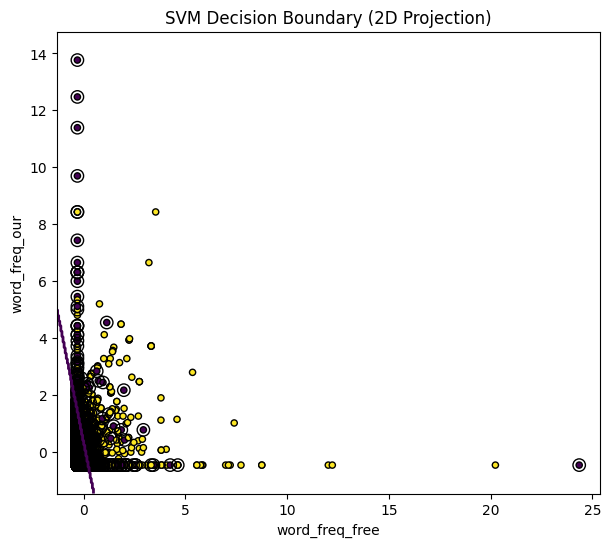

In [ ]:
# convert back to DataFrame for column selection
X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df  = pd.DataFrame(X_test, columns=X.columns)

# choose any two features
feat1 = "word_freq_free"
feat2 = "word_freq_our"

# extract 2 feature subset
X2_train = X_train_df[[feat1, feat2]]
X2_test  = X_test_df[[feat1, feat2]]

# train a linear SVM only on the 2 features
model_2d = SVC(kernel='linear', C=1)
model_2d.fit(X2_train, y_train)

# decision boundary plotting
x_min, x_max = X2_train.iloc[:, 0].min() - 1, X2_train.iloc[:, 0].max() + 1
y_min, y_max = X2_train.iloc[:, 1].min() - 1, X2_train.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))

Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7,6))
plt.contour(xx, yy, Z, levels=[0.5], linewidths=2)
plt.scatter(X2_train.iloc[:, 0], X2_train.iloc[:, 1], c=y_train, s=20, edgecolors='k')
plt.scatter(model_2d.support_vectors_[:, 0], model_2d.support_vectors_[:, 1], s=80, facecolors='none', edgecolors='k')
plt.xlabel(feat1)
plt.ylabel(feat2)
plt.title("SVM Decision Boundary (2D Projection)")
plt.show()

## Optimising for Other Evaluation Metrics

In this case, we had optimised (tuned) the model based on overall accuracy, though that may not always be the best metric to optimise. For example, if you are concerned more about catching all spams (positives), you may want to maximise TPR or sensitivity/recall. If, on the other hand, you want to avoid classifying hams as spams (so that any important mails don't get into the spam box), you would maximise the TNR or specificity.

In [141]:
# specify range of parameters (C) as a list
params = {"C": [0.001, 0.01, 0.1, 1, 10, 100]}

# specify scores/metrics in an iterable
scores = ['accuracy', 'recall']

for score in scores:
    print("# Tuning hyper-parameters for {}".format(score))

    # set up GridSearch for score metric
    clf = GridSearchCV(SVC(kernel='linear'), 
                       params, 
                       cv=folds,
                       scoring=score,
                       return_train_score=True)
    # fit
    clf.fit(X_train, y_train)

    print(" The highest {0} score is {1} at C = {2}".format(score, clf.best_score_, clf.best_params_))
    print("\n")   

# Tuning hyper-parameters for accuracy
 The highest accuracy score is 0.9322981366459627 at C = {'C': 100}


# Tuning hyper-parameters for recall
 The highest recall score is 0.9043180474049264 at C = {'C': 100}




Thus, you can see that the optimal value of the hyperparameter varies significantly with the choice of evaluation metric.